In [1]:
import os
import glob
import re
import rasterio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Effect of Resolution

Processing 40m Resolution...
Processing 20m Resolution...
Processing 10m Resolution...
Processing 5m Resolution...


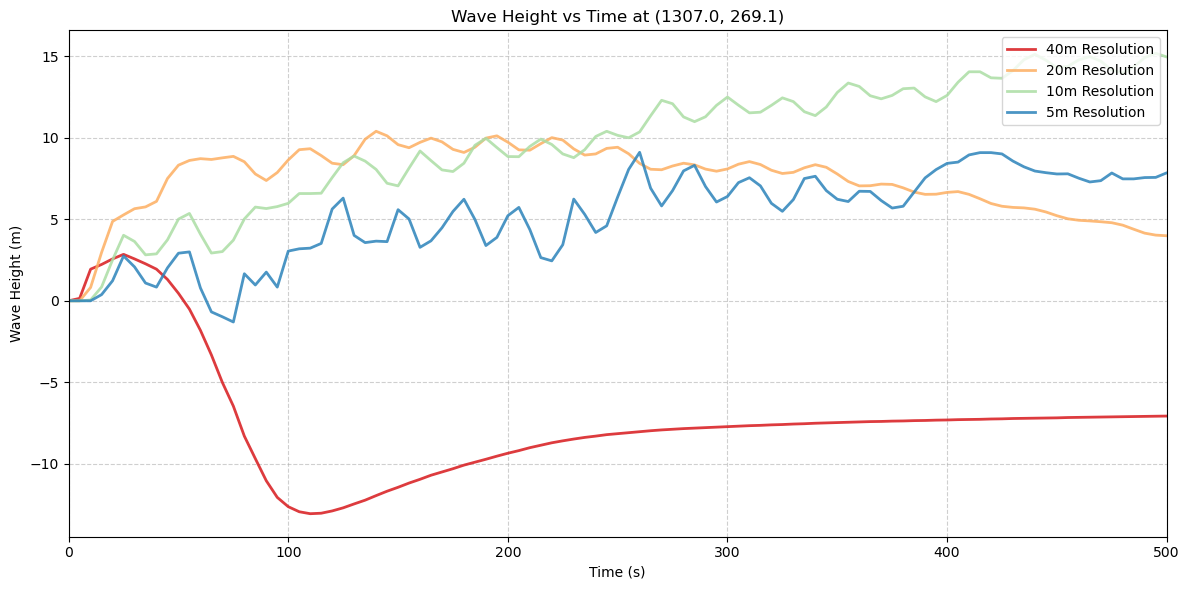

In [2]:
# Coords to extract data
TARGET_COORDINATE = (1307.0, 269.1) 

runs = {
    "40m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM40m/40m_results/40m_ascii",
        "prefix": "40m" 
    },
    "20m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM20m/20m_results/20m_ascii",
        "prefix": "20m"
    },
    "10m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM10m/10m_results/10m_ascii",
        "prefix": "10m"
    },
    "5m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM5m/5m_results/5m_ascii",
        "prefix": "5m"
    }
}

def extract_wave_data(results_dir, prefix, target_coord):

    search_pattern = os.path.join(results_dir, f"{prefix}_htsun[0-9]*.asc")
    file_list = glob.glob(search_pattern)
    
    if not file_list:
        print(f"Warning: No files found for prefix '{prefix}' in {results_dir}")
        return [], []

    pattern = re.compile(rf"{prefix}_htsun(\d+)\.asc")
    sorted_pairs = []
    
    for filepath in file_list:
        filename = os.path.basename(filepath)
        match = pattern.search(filename)
        if match:
            timestep = int(match.group(1))
            sorted_pairs.append((timestep, filepath))
            
    sorted_pairs.sort(key=lambda x: x[0])
    
    timesteps = [pair[0] * 5 for pair in sorted_pairs]
    ordered_files = [pair[1] for pair in sorted_pairs]
    wave_heights = []
    
    for file_path in ordered_files:
        with rasterio.open(file_path) as src:
            try:
                sampled_value = next(src.sample([target_coord]))[0]
                if sampled_value < -9000: 
                    wave_heights.append(0.0)
                else:
                    wave_heights.append(sampled_value)
            except IndexError:
                wave_heights.append(0.0)

    return timesteps, wave_heights


plt.figure(figsize=(12, 6))

# Use distinct colors to easily tell the grids apart
colors = ['#d7191c', '#fdae61', '#abdda4', '#2b83ba'] 

for (label, config), color in zip(runs.items(), colors):
    print(f"Processing {label}...")
    ts, hs = extract_wave_data(config['dir'], config['prefix'], TARGET_COORDINATE)
    
    if ts and hs:
        plt.plot(ts, hs, label=label, color=color, linewidth=2, alpha=0.85)

plt.title(f"Wave Height vs Time at {TARGET_COORDINATE}")
plt.xlabel("Time (s)")
plt.ylabel("Wave Height (m)")

plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, 500) 

plt.tight_layout()
plt.show()

## Fourier to extract freq

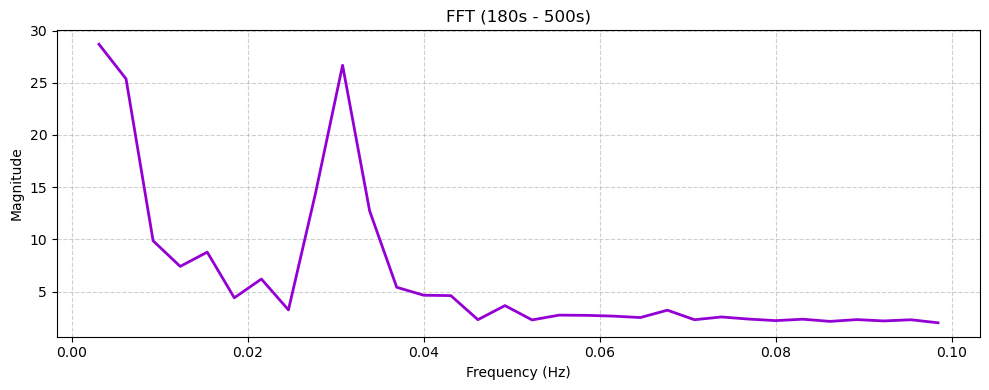

In [5]:
t_arr = np.array(timesteps)
h_arr = np.array(wave_heights)

# Slices the data to ONLY look at the timeline after 180 seconds
seiche_only_mask = t_arr > 180
t_seiche = t_arr[seiche_only_mask]
h_seiche = h_arr[seiche_only_mask]

# AI stuff from here
# Detrend just this clean seiche section
h_seiche_clean = h_seiche - np.mean(h_seiche)

# Compute FFT on the clean section
n_s = len(h_seiche_clean)
fft_vals_s = np.fft.rfft(h_seiche_clean)
frequencies_s = np.fft.rfftfreq(n_s, d=5)

# Plot the clean spectrum
plt.figure(figsize=(10, 4))
plt.plot(frequencies_s[1:], np.abs(fft_vals_s)[1:], color='darkviolet', linewidth=2)
plt.title("FFT (180s - 500s)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

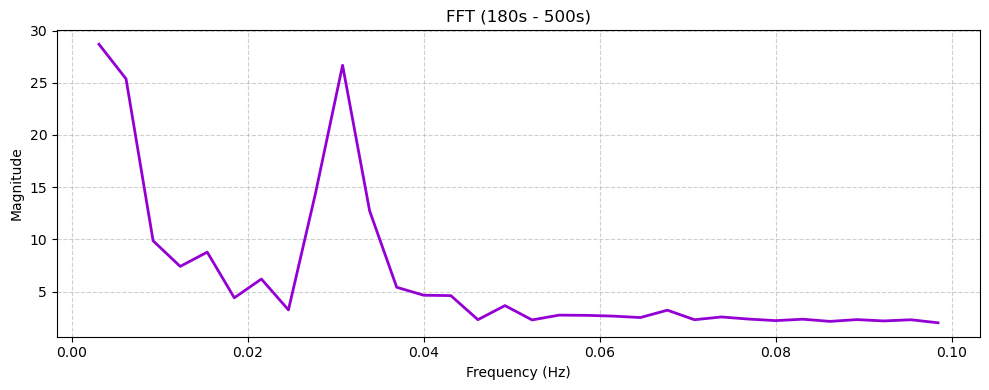

In [3]:
t_arr = np.array(timesteps)
h_arr = np.array(wave_heights)

# Slices the data to ONLY look at the timeline after 180 seconds
seiche_only_mask = t_arr > 180
t_seiche = t_arr[seiche_only_mask]
h_seiche = h_arr[seiche_only_mask]

# AI stuff from here
# Detrend just this clean seiche section
h_seiche_clean = h_seiche

# Compute FFT on the clean section
n_s = len(h_seiche_clean)
fft_vals_s = np.fft.rfft(h_seiche_clean)
frequencies_s = np.fft.rfftfreq(n_s, d=5)

# Plot the clean spectrum
plt.figure(figsize=(10, 4))
plt.plot(frequencies_s[1:], np.abs(fft_vals_s)[1:], color='darkviolet', linewidth=2)
plt.title("FFT (180s - 500s)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Effect of Changing Landslide Stuff

Processing Run A (200m x 20m)...
Processing Run B (400m x 10m)...
Processing Run C (100m x 40m)...


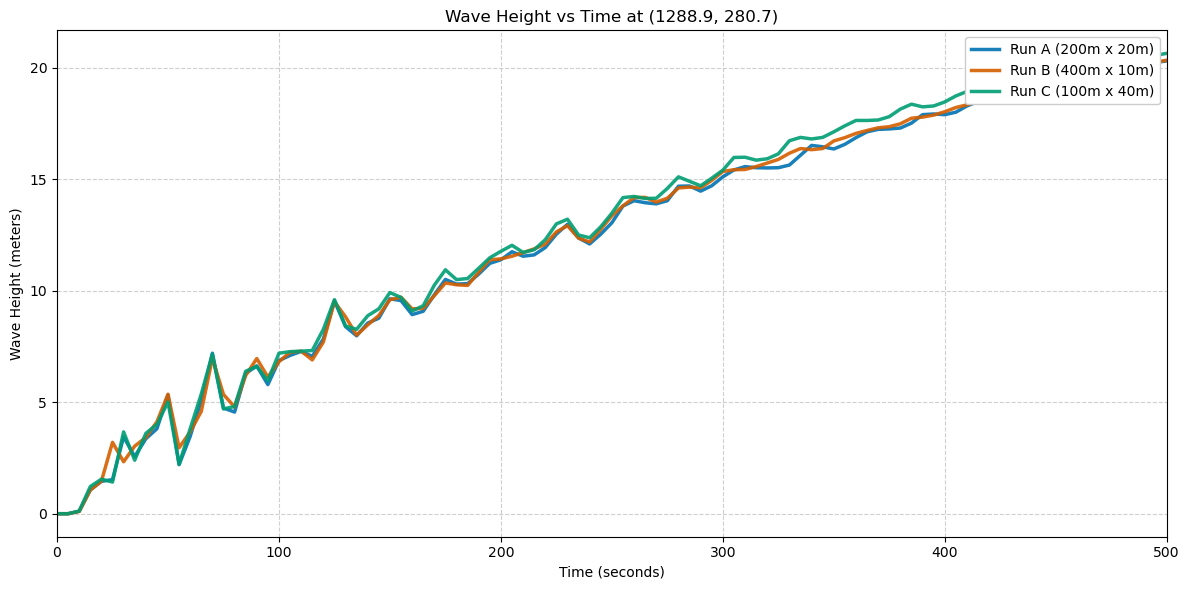

In [2]:
# We change the dimensions of the landslide block, specifically the length and thickness, keeping width constant, such that the total volume of the landslide remains same;
TARGET_COORDINATE = (1288.9, 280.7) 

runs = {
    "Run A (200m x 20m)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii",
        "prefix": "Test1" 
    },
    "Run B (400m x 10m)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test2/Test2_results/Test2_ascii",
        "prefix": "Test2" 
    },
    "Run C (100m x 40m)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test3/Test3_results/Test3_ascii",
        "prefix": "Test3" 
    }
}

def extract_wave_data(results_dir, prefix, target_coord):
    
    search_pattern = os.path.join(results_dir, f"{prefix}_hstun[0-9]*.asc")
    file_list = glob.glob(search_pattern)
    
    if not file_list:
        search_pattern = os.path.join(results_dir, f"{prefix}_htsun[0-9]*.asc")
        file_list = glob.glob(search_pattern)
        
    if not file_list:
        print(f"Warning: No files found for prefix '{prefix}' in {results_dir}")
        return [], []

    pattern = re.compile(rf"{prefix}_h[s,t]+un(\d+)\.asc")
    sorted_pairs = []
    
    for filepath in file_list:
        filename = os.path.basename(filepath)
        match = pattern.search(filename)
        if match:
            timestep = int(match.group(1))
            sorted_pairs.append((timestep, filepath))
            
    sorted_pairs.sort(key=lambda x: x[0])
    
    timesteps = [pair[0] * 5 for pair in sorted_pairs] 
    ordered_files = [pair[1] for pair in sorted_pairs]
    wave_heights = []
    
    for file_path in ordered_files:
        with rasterio.open(file_path) as src:
            try:
                sampled_value = next(src.sample([target_coord]))[0]
                if sampled_value < -9000:  
                    wave_heights.append(0.0)
                else:
                    wave_heights.append(sampled_value)
            except IndexError:
                wave_heights.append(0.0)

    return timesteps, wave_heights


plt.figure(figsize=(12, 6))

colors = ['#0072B2', '#D55E00', '#009E73'] 

for (label, config), color in zip(runs.items(), colors):
    print(f"Processing {label}...")
    ts, hs = extract_wave_data(config['dir'], config['prefix'], TARGET_COORDINATE)
    
    if ts and hs:
        plt.plot(ts, hs, label=label, color=color, linewidth=2.5, alpha=0.9) 

plt.title(f"Wave Height vs Time at {TARGET_COORDINATE}")
plt.xlabel("Time (seconds)")
plt.ylabel("Wave Height (meters)")

plt.legend(loc="upper right", framealpha=1.0) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, 500) 

plt.tight_layout()
plt.show()

Processing Run D (Volume: 120,000 $m^3$)...
Processing Run E (Volume: 240,000 $m^3$ - Baseline)...
Processing Run F (Volume: 480,000 $m^3$)...


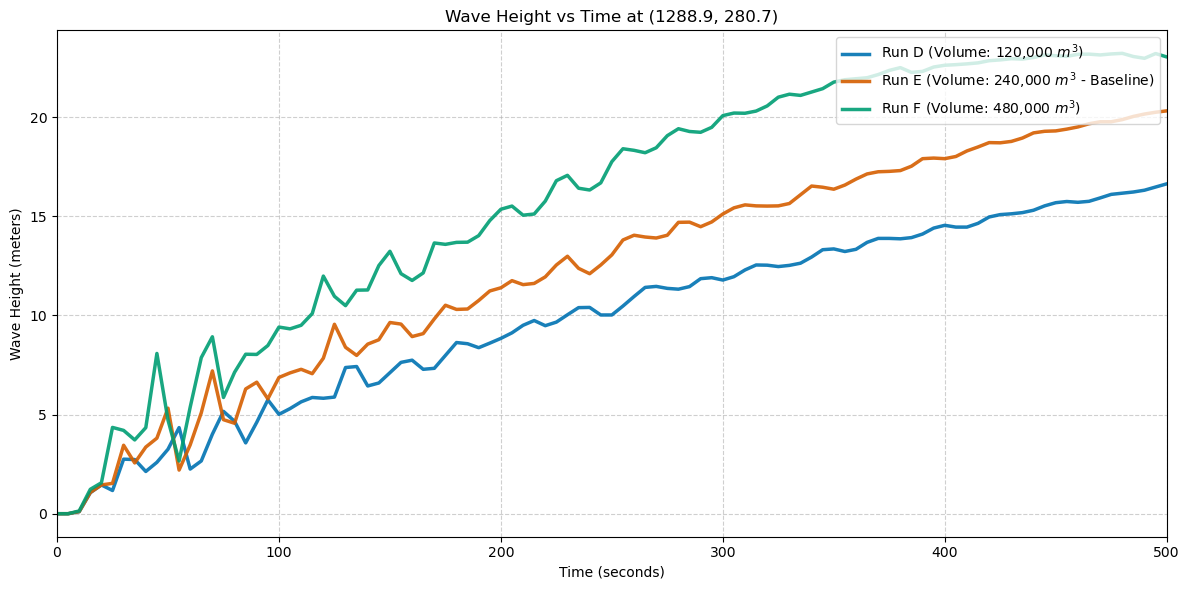

In [3]:
# WE change the volume but keep the dimensions the same; volume is changed by changing the thickness of the landslide block; 
TARGET_COORDINATE = (1288.9, 280.7) 

runs = {
    "Run D (Volume: 120,000 $m^3$)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test4/Test4_results/Test4_ascii",
        "prefix": "Test4" 
    },
    "Run E (Volume: 240,000 $m^3$ - Baseline)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii",
        "prefix": "Test1" 
    },
    "Run F (Volume: 480,000 $m^3$)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test5/Test5_results/Test5_ascii",
        "prefix": "Test5" 
    }
}

def extract_wave_data(results_dir, prefix, target_coord):
    
    search_pattern = os.path.join(results_dir, f"{prefix}_hstun[0-9]*.asc")
    file_list = glob.glob(search_pattern)
    
    if not file_list:
        search_pattern = os.path.join(results_dir, f"{prefix}_htsun[0-9]*.asc")
        file_list = glob.glob(search_pattern)
        
    if not file_list:
        print(f"Warning: No files found for prefix '{prefix}' in {results_dir}")
        return [], []

    pattern = re.compile(rf"{prefix}_h[s,t]+un(\d+)\.asc")
    sorted_pairs = []
    
    for filepath in file_list:
        filename = os.path.basename(filepath)
        match = pattern.search(filename)
        if match:
            timestep = int(match.group(1))
            sorted_pairs.append((timestep, filepath))
            
    sorted_pairs.sort(key=lambda x: x[0])
    
    timesteps = [pair[0] * 5 for pair in sorted_pairs] 
    ordered_files = [pair[1] for pair in sorted_pairs]
    wave_heights = []
    
    for file_path in ordered_files:
        with rasterio.open(file_path) as src:
            try:
                sampled_value = next(src.sample([target_coord]))[0]
                if sampled_value < -9000:  
                    wave_heights.append(0.0)
                else:
                    wave_heights.append(sampled_value)
            except IndexError:
                wave_heights.append(0.0)

    return timesteps, wave_heights


plt.figure(figsize=(12, 6))

colors = ['#0072B2', '#D55E00', '#009E73'] 

for (label, config), color in zip(runs.items(), colors):
    print(f"Processing {label}...")
    ts, hs = extract_wave_data(config['dir'], config['prefix'], TARGET_COORDINATE)
    
    if ts and hs:
        plt.plot(ts, hs, label=label, color=color, linewidth=2.5, alpha=0.9) 

plt.title(f"Wave Height vs Time at {TARGET_COORDINATE}")
plt.xlabel("Time (seconds)")
plt.ylabel("Wave Height (meters)")

plt.legend(loc="upper right") 
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, 500) 

plt.tight_layout()
plt.show()

## Attempt to extract freq to verify normal modes

In [2]:
%matplotlib qt
RESULTS_DIR = "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii"
PREFIX = "Test1"
TARGET_COORD = (1288.9, 280.7)
DT = 5
SEICHE_START = 180

def extract_wave_data(results_dir, prefix, target_coord):
    # Updated pattern to strictly use 'htsun'
    search_pattern = os.path.join(results_dir, f"{prefix}_htsun[0-9]*.asc")
    file_list = glob.glob(search_pattern)
    
    if not file_list:
        print(f"Error: No files found in {results_dir} matching {prefix}_htsun*.asc")
        # Diagnostic print to help you debug if it fails again
        print("Existing files:", os.listdir(results_dir)[:5] if os.path.exists(results_dir) else "Directory invalid")
        return np.array([]), np.array([])

    pattern = re.compile(rf"{prefix}_htsun(\d+)\.asc")
    sorted_pairs = []
    
    for filepath in file_list:
        match = pattern.search(os.path.basename(filepath))
        if match:
            timestep = int(match.group(1))
            sorted_pairs.append((timestep, filepath))
            
    sorted_pairs.sort(key=lambda x: x[0])
    
    timesteps = np.array([pair[0] * DT for pair in sorted_pairs])
    wave_heights = []
    
    for _, file_path in sorted_pairs:
        with rasterio.open(file_path) as src:
            try:
                val = next(src.sample([target_coord]))[0]
                wave_heights.append(0.0 if val < -9000 else val)
            except IndexError:
                wave_heights.append(0.0)

    return timesteps, np.array(wave_heights)

# 1. Extraction
ts, hs = extract_wave_data(RESULTS_DIR, PREFIX, TARGET_COORD)

if len(ts) > 0:
    # 2. Seiche Isolation (Start after initial impact)
    mask = ts >= SEICHE_START
    t_seiche = ts[mask]
    h_seiche = hs[mask]
    
    # 3. Detrending (Remove mean level)
    h_clean = h_seiche - np.mean(h_seiche)
    n = len(h_clean)
    
    # 4. FFT Computation
    fft_vals = np.fft.rfft(h_clean)
    freqs = np.fft.rfftfreq(n, d=DT)
    
    # 5. Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(freqs[1:], np.abs(fft_vals)[1:], color='#0072B2', linewidth=2.5)
    
    plt.title(f"FFT Spectrum: {PREFIX} at {TARGET_COORD}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("FFT Magnitude")
    plt.grid(True, linestyle='--', alpha=0.6)# Adjust limit to focus on your peaks
    plt.tight_layout()
    plt.show()

# Checking Volume Conservation

In [ ]:
# FINAL VOLUME
def calculate_total_volume(filepath, cell_size=10):
    with rasterio.open(filepath) as src:
        data = src.read(1)
        # We only care about positive heights (deposition/water)
        data[data < 0] = 0 
        volume = np.sum(data) * (cell_size**2)
    return volume

solid_file = "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii/Test1_hflow10101.asc"
fluid_file = "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii/Test1_hflow20101.asc"

vol_solid = calculate_total_volume(solid_file)
vol_fluid = calculate_total_volume(fluid_file)

total_final_volume = vol_solid + vol_fluid

print(f"Final Solid Volume: {vol_solid:.2f} m3")
print(f"Final Fluid Volume: {vol_fluid:.2f} m3")
print(f"Total System Volume: {total_final_volume:.2f} m3")

Final Solid Volume: 7597618.00 m3
Final Fluid Volume: 0.00 m3
Total System Volume: 7597618.00 m3


In [ ]:
# INITIAL VOLUME
def calculate_total_volume(filepath, cell_size=10):
    with rasterio.open(filepath) as src:
        data = src.read(1)
        # We only care about positive heights (deposition/water)
        data[data < 0] = 0 
        volume = np.sum(data) * (cell_size**2)
    return volume

solid_file = "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii/Test1_hflow10000.asc"
fluid_file = "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii/Test1_hflow30000.asc"

vol_solid = calculate_total_volume(solid_file)
vol_fluid = calculate_total_volume(fluid_file)

total_initial_volume = vol_solid + vol_fluid

print(f"Initial Solid Volume: {vol_solid:.2f} m3")
print(f"Initial Fluid Volume: {vol_fluid:.2f} m3")
print(f"Total System Volume: {total_initial_volume:.2f} m3")

Final Solid Volume: 240000.00 m3
Final Fluid Volume: 33600000.00 m3
Total System Volume: 33840000.00 m3


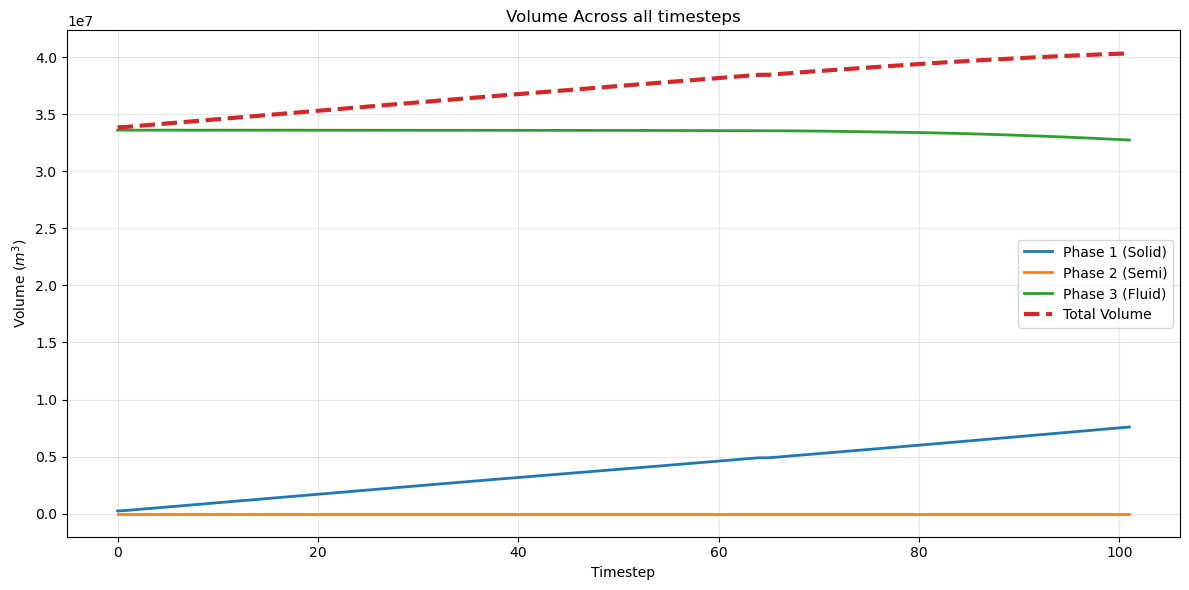

In [ ]:
CELL_SIZE = 10  # meters

base_dir = "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii"

start_step = 0
end_step = 101

def calculate_total_volume(filepath):
    with rasterio.open(filepath) as src:
        data = src.read(1)
        
        # Use the actual NoData value from the file header
        nodata_val = src.nodata
        
        # Mask NoData values and values below 0 (assuming negative depth is impossible)
        if nodata_val is not None:
            data[data == nodata_val] = 0
            
        data[data < 0] = 0
        
        # Calculate volume
        # Ensure your cell size matches src.res[0] * src.res[1]
        cell_area = src.res[0] * src.res[1] 
        volume = np.sum(data) * cell_area
        
    return volume

timesteps = []

phase1_volumes = []
phase2_volumes = []
phase3_volumes = []

total_volumes = []

for step in range(start_step, end_step + 1):

    step_str = f"{step:04d}"

    p1_file = os.path.join(
        base_dir,
        f"Test1_hflow1{step_str}.asc"
    )

    p2_file = os.path.join(
        base_dir,
        f"Test1_hflow2{step_str}.asc"
    )

    p3_file = os.path.join(
        base_dir,
        f"Test1_hflow3{step_str}.asc"
    )

    vol1 = calculate_total_volume(p1_file)
    vol2 = calculate_total_volume(p2_file)
    vol3 = calculate_total_volume(p3_file)

    total_volume = vol1 + vol2 + vol3

    timesteps.append(step)

    phase1_volumes.append(vol1)
    phase2_volumes.append(vol2)
    phase3_volumes.append(vol3)

    total_volumes.append(total_volume)


plt.figure(figsize=(12,6))

plt.plot(
    timesteps,
    phase1_volumes,
    label="Phase 1 (Solid)",
    linewidth=2
)

plt.plot(
    timesteps,
    phase2_volumes,
    label="Phase 2 (Semi)",
    linewidth=2
)

plt.plot(
    timesteps,
    phase3_volumes,
    label="Phase 3 (Fluid)",
    linewidth=2
)

plt.plot(
    timesteps,
    total_volumes,
    label="Total Volume",
    linewidth=3,
    linestyle="--"
)

plt.xlabel("Timestep")
plt.ylabel("Volume ($m^3$)")

plt.title("Volume Across all timesteps")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()